In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

missing[missing["missing_count"] > 0]

,missing_count,missing_percent


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [7]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


    

    *****************


--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
5855-EIBDE    1
8166-ZZTFS    1
0129-KPTWJ    1
9128-CPXKI    1
9509-MPYOD    1
Name: count, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No            

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [9]:
# Create a fresh working copy from the original raw dataframe
df_clean = df.copy()

# Clean and convert TotalCharges
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"].astype("string").str.strip(),
    errors="coerce"
)

# Check missing values created during conversion
print(
    "Missing TotalCharges after conversion:",
    df_clean["TotalCharges"].isna().sum()
)

# Inspect those records
df_clean[df_clean["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

Missing TotalCharges after conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,<NA>,No
753,3115-CZMZD,0,20.25,<NA>,No
936,5709-LVOEQ,0,80.85,<NA>,No
1082,4367-NUYAO,0,25.75,<NA>,No
1340,1371-DWPAZ,0,56.05,<NA>,No
3331,7644-OMVMY,0,19.85,<NA>,No
3826,3213-VVOLG,0,25.35,<NA>,No
4380,2520-SGTTA,0,20.00,<NA>,No
5218,2923-ARZLG,0,19.70,<NA>,No
6670,4075-WKNIU,0,73.35,<NA>,No


In [10]:
df_clean[df_clean["TotalCharges"].isna()]["tenure"].value_counts()

**************

tenure
0    11
Name: count, dtype: int64

In [11]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [12]:
# Convert churn target to binary
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [13]:
df_clean["Churn"].value_counts()


****************

Churn
0    5174
1    1869
Name: count, dtype: int64

In [14]:
# Tenure in years
df_clean["tenure_years"] = df_clean["tenure"] / 12

# Average monthly spend
df_clean["avg_monthly_spend"] = np.where(
    df_clean["tenure"] > 0,
    df_clean["TotalCharges"] / df_clean["tenure"],
    df_clean["MonthlyCharges"]
)

# Count subscribed services
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_clean["service_count"] = (
    df_clean[service_cols]
    .apply(lambda row: sum(value == "Yes" for value in row), axis=1)
)

In [15]:
print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

print("\nNew features:")
print(
    df_clean[
        [
            "tenure",
            "tenure_years",
            "MonthlyCharges",
            "TotalCharges",
            "avg_monthly_spend",
            "service_count",
            "Churn"
        ]
    ].head()
)

Shape: (7043, 24)

Missing values:
Series([], dtype: int64)

New features:
   tenure  tenure_years  MonthlyCharges  TotalCharges  avg_monthly_spend  \
0       1      0.083333           29.85         29.85          29.850000   
1      34      2.833333           56.95        1889.5          55.573529   
2       2      0.166667           53.85        108.15          54.075000   
3      45      3.750000           42.30       1840.75          40.905556   
4       2      0.166667           70.70        151.65          75.825000   

   service_count  Churn  
0              1      0  
1              3      0  
2              3      1  
3              3      0  
4              1      1  


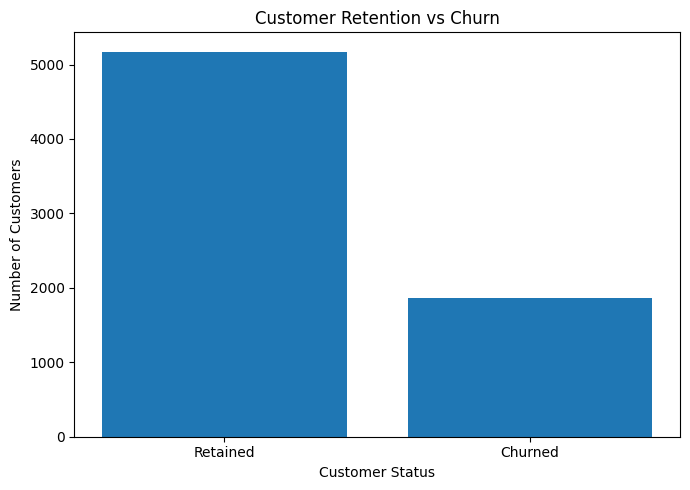

In [16]:
import matplotlib.pyplot as plt

churn_counts = df_clean["Churn"].value_counts().sort_index()

labels = ["Retained", "Churned"]

plt.figure(figsize=(7, 5))
plt.bar(labels, churn_counts.values)
plt.title("Customer Retention vs Churn")
plt.ylabel("Number of Customers")
plt.xlabel("Customer Status")
plt.tight_layout()
plt.show()

In [17]:
churn_summary = (
    df_clean["Churn"]
    .value_counts(normalize=True)
    .rename({0: "Retained", 1: "Churned"})
    .mul(100)
    .round(2)
)

print(churn_summary)

Churn
Retained    73.46
Churned     26.54
Name: proportion, dtype: float64


<Figure size 800x500 with 0 Axes>

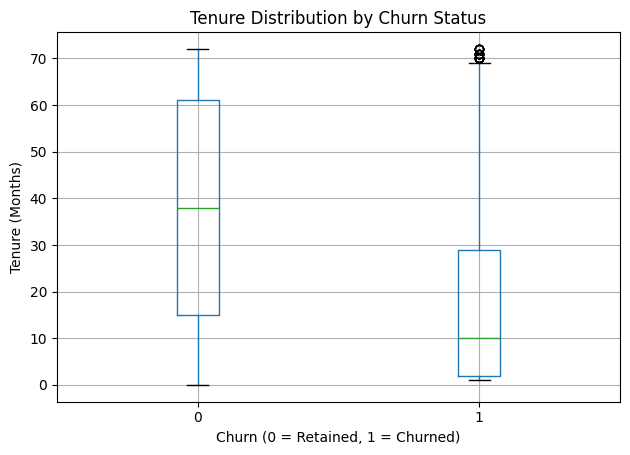

In [18]:
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

In [19]:
tenure_summary = (
    df_clean.groupby("Churn")["tenure"]
    .agg(["mean", "median"])
    .rename(index={0: "Retained", 1: "Churned"})
)

print(tenure_summary)

               mean  median
Churn                      
Retained  37.569965    38.0
Churned   17.979133    10.0


In [20]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.rename(
    columns={0: "Retained", 1: "Churned"}
)

print(contract_churn.round(2))

Churn           Retained  Churned
Contract                         
Month-to-month     57.29    42.71
One year           88.73    11.27
Two year           97.17     2.83


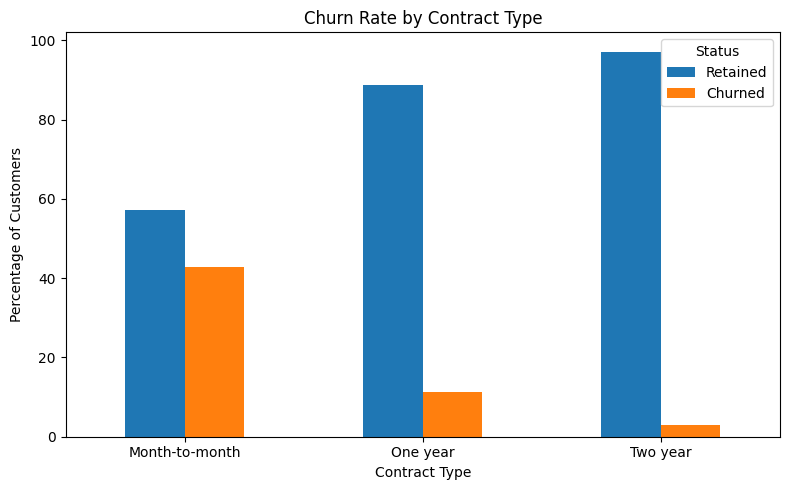

In [21]:
contract_churn[["Retained", "Churned"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [22]:
charges_summary = (
    df_clean.groupby("Churn")["MonthlyCharges"]
    .agg(["mean", "median"])
    .rename(index={0: "Retained", 1: "Churned"})
)

print(charges_summary.round(2))

           mean  median
Churn                  
Retained  61.27   64.43
Churned   74.44   79.65


<Figure size 800x500 with 0 Axes>

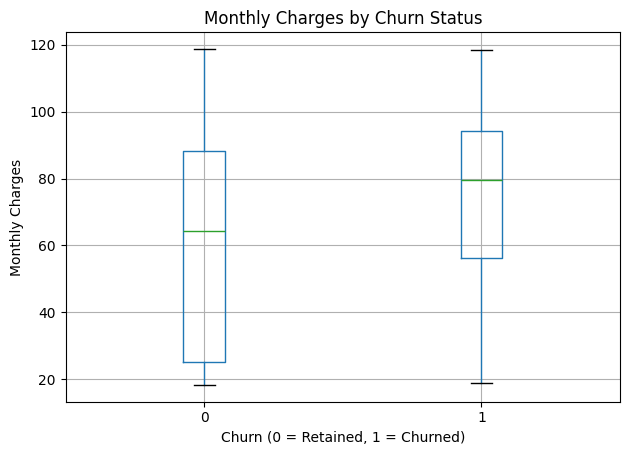

In [23]:
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()


In [24]:
categorical_cols = [
    "InternetService",
    "Contract",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "PaperlessBilling"
]

for col in categorical_cols:
    summary = (
        pd.crosstab(
            df_clean[col],
            df_clean["Churn"],
            normalize="index"
        ) * 100
    )

    summary = summary.rename(
        columns={0: "Retained", 1: "Churned"}
    )

    print(f"\n--- {col} ---")
    print(summary.round(2))


--- InternetService ---
Churn            Retained  Churned
InternetService                   
DSL                 81.04    18.96
Fiber optic         58.11    41.89
No                  92.60     7.40

--- Contract ---
Churn           Retained  Churned
Contract                         
Month-to-month     57.29    42.71
One year           88.73    11.27
Two year           97.17     2.83

--- PaymentMethod ---
Churn                      Retained  Churned
PaymentMethod                               
Bank transfer (automatic)     83.29    16.71
Credit card (automatic)       84.76    15.24
Electronic check              54.71    45.29
Mailed check                  80.89    19.11

--- TechSupport ---
Churn                Retained  Churned
TechSupport                           
No                      58.36    41.64
No internet service     92.60     7.40
Yes                     84.83    15.17

--- OnlineSecurity ---
Churn                Retained  Churned
OnlineSecurity                        
N

In [25]:
print(df_clean.shape)
print(df_clean.columns.tolist())
print(df_clean.head())

print(df_clean.dtypes)

(7043, 24)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_years', 'avg_monthly_spend', 'service_count']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0  No phone service             DSL             No  ...

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Target
y = df_clean["Churn"]

# Remove ID and target
X = df_clean.drop(columns=["customerID", "Churn"])

print("Features:", X.shape)
print("Target:", y.shape)




*****************************************************

Features: (7043, 22)
Target: (7043,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining churn rate:")
print(y_train.mean().round(3))

print("\nTesting churn rate:")
print(y_test.mean().round(3))

Training set: (5634, 22)
Testing set: (1409, 22)

Training churn rate:
0.265

Testing churn rate:
0.265


In [28]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_years', 'avg_monthly_spend', 'service_count']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [30]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]



In [31]:
print("LOGISTIC REGRESSION")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_lr), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_lr), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_lr), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_lr), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_lr), 4
))

LOGISTIC REGRESSION
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.604
ROC-AUC  : 0.8423


In [32]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [33]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [34]:
print("RANDOM FOREST")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_rf), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_rf), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_rf), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_rf), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_rf), 4
))

RANDOM FOREST
Accuracy : 0.8013
Precision: 0.661
Recall   : 0.516
F1 Score : 0.5796
ROC-AUC  : 0.843


In [35]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [36]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8423
1,Random Forest,0.8013,0.6610,0.5160,0.5796,0.8430


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Features and target
X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True).astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.7899
Precision: 0.6364
Recall   : 0.4866
F1 Score : 0.5515
ROC-AUC  : 0.8288


In [79]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(15)

,Feature,Importance
0,TotalCharges,0.121395
1,tenure_years,0.111091
2,avg_monthly_spend,0.109295
3,MonthlyCharges,0.106238
4,tenure,0.104212
5,Contract_Two year,0.050322
6,InternetService_Fiber optic,0.035833
7,PaymentMethod_Electronic check,0.032618
8,service_count,0.030562
9,Contract_One year,0.023626


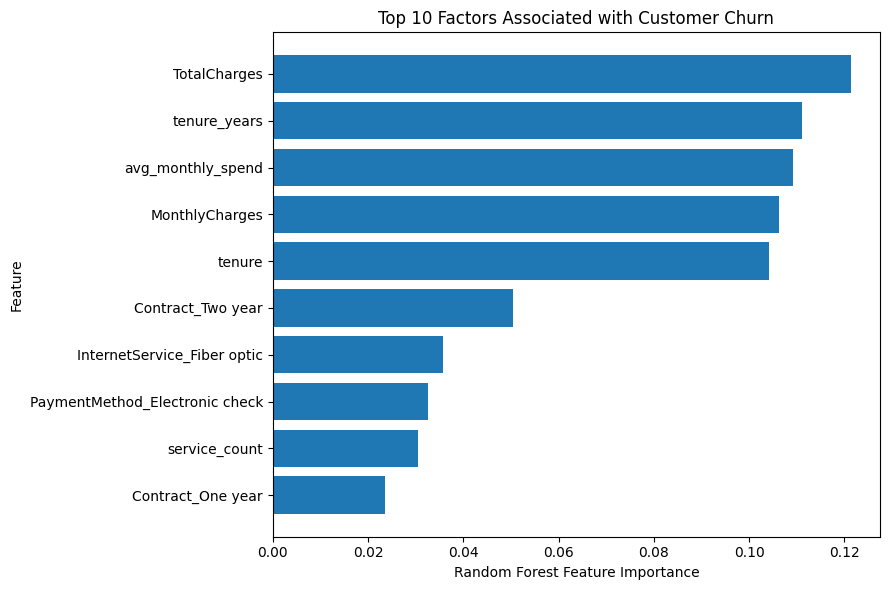

In [80]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Factors Associated with Customer Churn")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

['LogisticRegression', 'logistic_model']


In [42]:
print(logistic_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'tenure_years',
                                                   'avg_monthly_spend',
                                                   'service_count']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                       

In [44]:
# Extract preprocessing and classifier
preprocessor = logistic_model.named_steps["preprocessor"]
logreg = logistic_model.named_steps["classifier"]

# Get the transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logreg.coef_[0]

# Create dataframe
logreg_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient
logreg_coefficients["Abs_Coefficient"] = (
    logreg_coefficients["Coefficient"].abs()
)

# Sort by absolute effect
logreg_coefficients = (
    logreg_coefficients
    .sort_values("Abs_Coefficient", ascending=False)
    .reset_index(drop=True)
)

logreg_coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
0,cat__Contract_Two year,-1.343246,1.343246
1,cat__InternetService_Fiber optic,1.219949,1.219949
2,cat__Contract_One year,-0.690974,0.690974
3,num__tenure_years,-0.631737,0.631737
4,num__tenure,-0.631737,0.631737
5,num__MonthlyCharges,-0.590747,0.590747
6,num__TotalCharges,0.537882,0.537882
7,cat__OnlineSecurity_Yes,-0.497784,0.497784
8,cat__PhoneService_Yes,-0.453744,0.453744
9,cat__TechSupport_Yes,-0.449402,0.449402


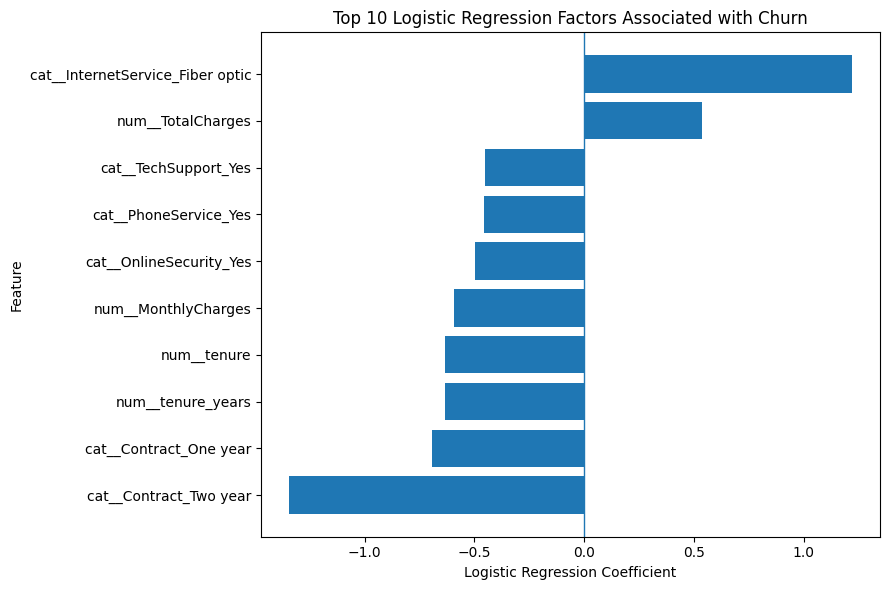

In [45]:
top_logreg = logreg_coefficients.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_logreg["Feature"],
    top_logreg["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Top 10 Logistic Regression Factors Associated with Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [46]:
# Check correlation among numerical features

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "tenure_years",
    "avg_monthly_spend",
    "service_count"
]

correlation_matrix = df_clean[numeric_features].corr()

correlation_matrix.round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,tenure_years,avg_monthly_spend,service_count
SeniorCitizen,1.00,0.02,0.22,0.10,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83,1.00,0.25,0.52
MonthlyCharges,0.22,0.25,1.00,0.65,0.25,1.00,0.80
TotalCharges,0.10,0.83,0.65,1.00,0.83,0.65,0.80
tenure_years,0.02,1.00,0.25,0.83,1.00,0.25,0.52
avg_monthly_spend,0.22,0.25,1.00,0.65,0.25,1.00,0.80
service_count,0.10,0.52,0.80,0.80,0.52,0.80,1.00


In [47]:
# Remove redundant derived features
X_reduced = df_clean.drop(
    columns=[
        "Churn",
        "customerID",
        "tenure_years",
        "avg_monthly_spend"
    ]
)

y = df_clean["Churn"]

In [50]:
from sklearn.model_selection import train_test_split

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_red.shape)
print("Testing shape:", X_test_red.shape)

Training shape: (5634, 20)
Testing shape: (1409, 20)


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features_red = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_count"
]

categorical_features_red = [
    col for col in X_reduced.columns
    if col not in numeric_features_red
]

preprocessor_red = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_red),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), categorical_features_red)
    ]
)

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model_reduced = Pipeline(
    steps=[
        ("preprocessor", preprocessor_red),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model_reduced.fit(
    X_train_red,
    y_train_red
)

print("Reduced Logistic Regression trained successfully.")

Reduced Logistic Regression trained successfully.


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_lr_red = logistic_model_reduced.predict(X_test_red)
y_prob_lr_red = logistic_model_reduced.predict_proba(X_test_red)[:, 1]

lr_red_results = {
    "Model": "Logistic Regression - Reduced",
    "Accuracy": accuracy_score(y_test_red, y_pred_lr_red),
    "Precision": precision_score(y_test_red, y_pred_lr_red),
    "Recall": recall_score(y_test_red, y_pred_lr_red),
    "F1": f1_score(y_test_red, y_pred_lr_red),
    "ROC-AUC": roc_auc_score(y_test_red, y_prob_lr_red)
}

lr_red_results

{'Model': 'Logistic Regression - Reduced',
 'Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1': 0.6040462427745664,
 'ROC-AUC': 0.8422666563331527}

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model_reduced = Pipeline(
    steps=[
        ("preprocessor", preprocessor_red),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model_reduced.fit(
    X_train_red,
    y_train_red
)

print("Reduced Random Forest trained successfully.")

Reduced Random Forest trained successfully.


In [55]:
y_pred_rf_red = rf_model_reduced.predict(X_test_red)
y_prob_rf_red = rf_model_reduced.predict_proba(X_test_red)[:, 1]

rf_red_results = {
    "Model": "Random Forest - Reduced",
    "Accuracy": accuracy_score(y_test_red, y_pred_rf_red),
    "Precision": precision_score(y_test_red, y_pred_rf_red),
    "Recall": recall_score(y_test_red, y_pred_rf_red),
    "F1": f1_score(y_test_red, y_pred_rf_red),
    "ROC-AUC": roc_auc_score(y_test_red, y_prob_rf_red)
}

rf_red_results

{'Model': 'Random Forest - Reduced',
 'Accuracy': 0.7806955287437899,
 'Precision': 0.6109215017064846,
 'Recall': 0.4786096256684492,
 'F1': 0.5367316341829086,
 'ROC-AUC': 0.8249115192849208}

<Figure size 800x600 with 0 Axes>

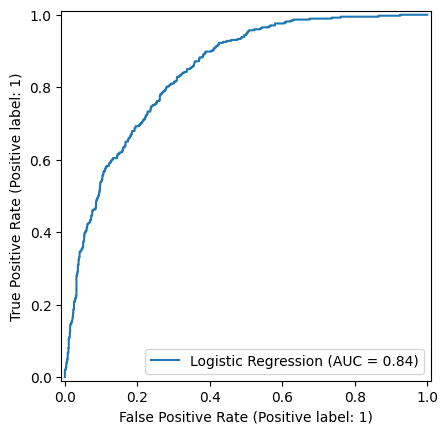

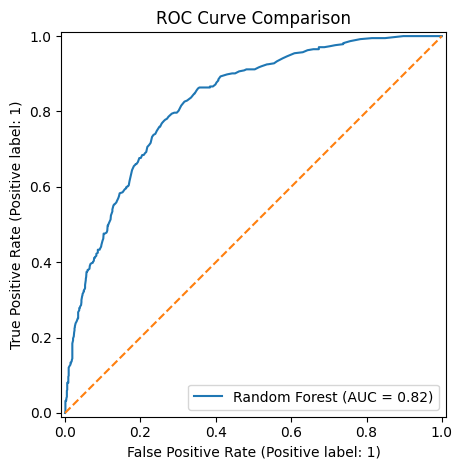

In [60]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test_red,
    y_prob_lr_red,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test_red,
    y_prob_rf_red,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

In [61]:
# Extract coefficients from the final reduced Logistic Regression

logreg_final = logistic_model_reduced

# Get transformed feature names
feature_names = (
    logreg_final
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get coefficients
coefficients = (
    logreg_final
    .named_steps["classifier"]
    .coef_[0]
)

final_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

final_coefficients["Abs_Coefficient"] = (
    final_coefficients["Coefficient"].abs()
)

final_coefficients = (
    final_coefficients
    .sort_values("Abs_Coefficient", ascending=False)
    .reset_index(drop=True)
)

final_coefficients.head(20)

,Feature,Coefficient,Abs_Coefficient
0,cat__Contract_Two year,-1.320682,1.320682
1,num__tenure,-1.258963,1.258963
2,cat__InternetService_Fiber optic,1.215182,1.215182
3,cat__Contract_One year,-0.688977,0.688977
4,num__TotalCharges,0.532223,0.532223
5,cat__OnlineSecurity_Yes,-0.516141,0.516141
6,num__MonthlyCharges,-0.513661,0.513661
7,cat__PhoneService_Yes,-0.482730,0.482730
8,cat__TechSupport_Yes,-0.463534,0.463534
9,cat__PaymentMethod_Electronic check,0.379284,0.379284


In [63]:
# Convert Logistic Regression coefficients into Odds Ratios

final_coefficients = final_coefficients.copy()

final_coefficients["Odds_Ratio"] = (
    np.exp(final_coefficients["Coefficient"])
)

final_coefficients["Odds_Ratio"] = (
    final_coefficients["Odds_Ratio"].round(3)
)

final_coefficients.head(10)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
0,cat__Contract_Two year,-1.320682,1.320682,0.267
1,num__tenure,-1.258963,1.258963,0.284
2,cat__InternetService_Fiber optic,1.215182,1.215182,3.371
3,cat__Contract_One year,-0.688977,0.688977,0.502
4,num__TotalCharges,0.532223,0.532223,1.703
5,cat__OnlineSecurity_Yes,-0.516141,0.516141,0.597
6,num__MonthlyCharges,-0.513661,0.513661,0.598
7,cat__PhoneService_Yes,-0.482730,0.482730,0.617
8,cat__TechSupport_Yes,-0.463534,0.463534,0.629
9,cat__PaymentMethod_Electronic check,0.379284,0.379284,1.461


In [64]:
# Predicted probabilities from the reduced Logistic Regression model
y_prob_lr_red = logistic_model_reduced.predict_proba(X_test_red)[:, 1]

y_prob_lr_red[:5]

array([0.04607137, 0.68350076, 0.05933911, 0.39983941, 0.02172207])

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    
    y_pred_threshold = (y_prob_lr_red >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_red, y_pred_threshold),
        "Precision": precision_score(y_test_red, y_pred_threshold),
        "Recall": recall_score(y_test_red, y_pred_threshold),
        "F1": f1_score(y_test_red, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.7495,0.5193,0.7540,0.6150
1,0.35,0.7637,0.5421,0.7059,0.6132
2,0.40,0.7786,0.5708,0.6684,0.6158
3,0.45,0.7885,0.5990,0.6150,0.6069
4,0.50,0.8055,0.6572,0.5588,0.6040
5,0.55,0.7991,0.6784,0.4626,0.5501
6,0.60,0.7999,0.7190,0.4037,0.5171
7,0.65,0.7899,0.7532,0.3102,0.4394
8,0.70,0.7665,0.7419,0.1845,0.2955


In [66]:
# Final threshold
final_threshold = 0.40

y_pred_final = (y_prob_lr_red >= final_threshold).astype(int)

# Final metrics
final_accuracy = accuracy_score(y_test_red, y_pred_final)
final_precision = precision_score(y_test_red, y_pred_final)
final_recall = recall_score(y_test_red, y_pred_final)
final_f1 = f1_score(y_test_red, y_pred_final)

print("Final Logistic Regression Model")
print("--------------------------------")
print("Threshold :", final_threshold)
print("Accuracy  :", round(final_accuracy, 4))
print("Precision :", round(final_precision, 4))
print("Recall    :", round(final_recall, 4))
print("F1 Score  :", round(final_f1, 4))

Final Logistic Regression Model
--------------------------------
Threshold : 0.4
Accuracy  : 0.7786
Precision : 0.5708
Recall    : 0.6684
F1 Score  : 0.6158


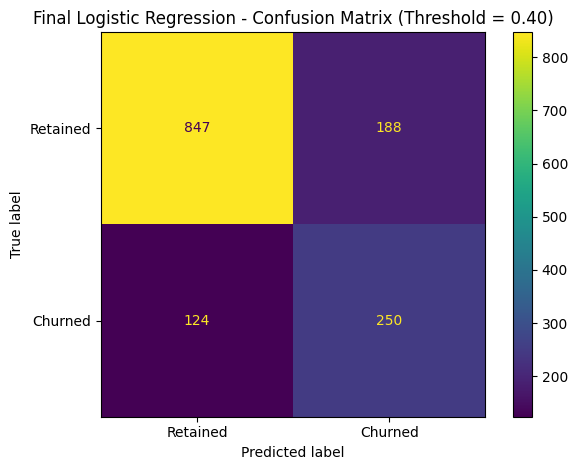

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Final confusion matrix at threshold 0.40
cm_final = confusion_matrix(y_test_red, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Retained", "Churned"]
)

disp.plot()
plt.title("Final Logistic Regression - Confusion Matrix (Threshold = 0.40)")
plt.tight_layout()
plt.show()

In [68]:
from sklearn.metrics import classification_report, roc_auc_score

print("FINAL LOGISTIC REGRESSION MODEL")
print("=" * 40)

print(f"Threshold : {final_threshold}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_red, y_prob_lr_red):.4f}")

print("\nClassification Report")
print("=" * 40)

print(
    classification_report(
        y_test_red,
        y_pred_final,
        target_names=["Retained", "Churned"]
    )
)

FINAL LOGISTIC REGRESSION MODEL
Threshold : 0.4
Accuracy  : 0.7786
Precision : 0.5708
Recall    : 0.6684
F1 Score  : 0.6158
ROC-AUC   : 0.8423

Classification Report
              precision    recall  f1-score   support

    Retained       0.87      0.82      0.84      1035
     Churned       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [69]:
from sklearn.metrics import balanced_accuracy_score

cm = confusion_matrix(y_test_red, y_pred_final)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
npv = tn / (tn + fn)
balanced_acc = balanced_accuracy_score(y_test_red, y_pred_final)

print("Additional Final Metrics")
print("=" * 35)
print(f"Specificity         : {specificity:.4f}")
print(f"NPV                 : {npv:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")

Additional Final Metrics
Specificity         : 0.8184
NPV                 : 0.8723
Balanced Accuracy   : 0.7434


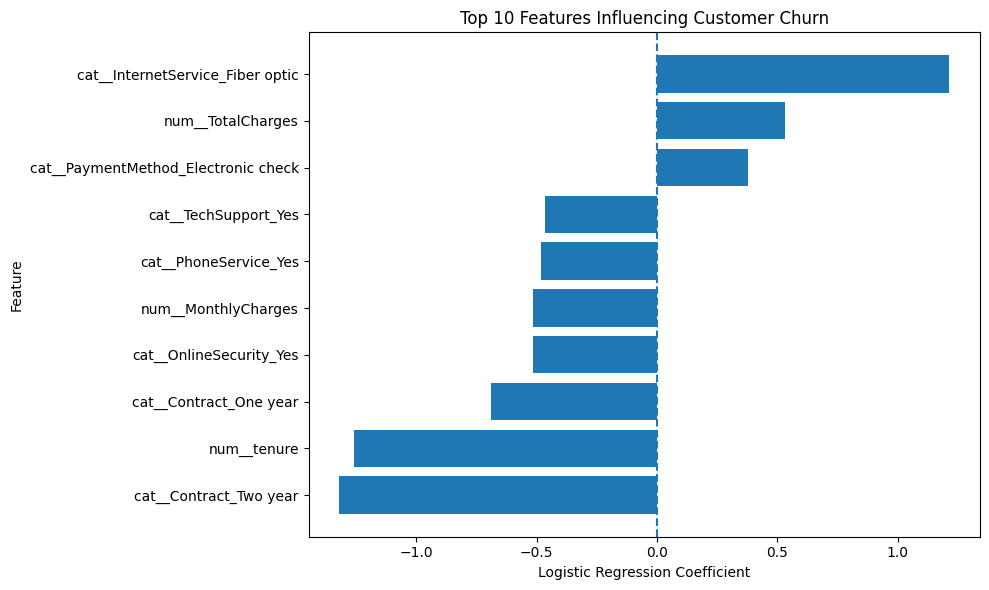

In [70]:
import matplotlib.pyplot as plt

# Top 10 features by absolute coefficient
plot_data = (
    final_coefficients
    .sort_values("Abs_Coefficient", ascending=False)
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Customer Churn")

plt.tight_layout()
plt.show()

In [71]:
business_insights = pd.DataFrame({
    "Factor": [
        "Fiber optic Internet",
        "Electronic check payment",
        "Two-year contract",
        "Tenure",
        "One-year contract",
        "Online Security",
        "Tech Support"
    ],
    "Impact": [
        "Higher churn risk",
        "Higher churn risk",
        "Lower churn risk",
        "Lower churn risk",
        "Lower churn risk",
        "Lower churn risk",
        "Lower churn risk"
    ],
    "Odds_Ratio": [
        3.371,
        1.461,
        0.267,
        0.284,
        0.502,
        0.597,
        0.629
    ]
})

business_insights

,Factor,Impact,Odds_Ratio
0,Fiber optic Internet,Higher churn risk,3.371
1,Electronic check payment,Higher churn risk,1.461
2,Two-year contract,Lower churn risk,0.267
3,Tenure,Lower churn risk,0.284
4,One-year contract,Lower churn risk,0.502
5,Online Security,Lower churn risk,0.597
6,Tech Support,Lower churn risk,0.629


In [73]:
print("FINAL CONCLUSION")
print("=" * 60)

print("""
The final customer churn prediction model was developed using
Logistic Regression with a reduced set of important features.

The model achieved a ROC-AUC of 0.8423, indicating good ability
to distinguish between retained and churned customers.

A probability threshold of 0.40 was selected to improve churn
detection. At this threshold, the model achieved 77.86% accuracy,
66.84% recall, 57.08% precision, and an F1-score of 61.58%.

The analysis identified several important factors associated
with customer churn. Fiber optic Internet service and electronic
check payments were associated with higher churn risk, while
longer tenure, one-year and two-year contracts, Online Security,
and Tech Support were associated with lower churn risk.

From a business perspective, the model can be used to identify
customers who are more likely to churn and prioritize them for
retention activities. Retention strategies could focus on
high-risk customers, encouraging longer-term contracts,
promoting support and security services, and investigating
payment-method-related churn patterns.

Overall, the final Logistic Regression model provides a
reasonably strong, interpretable, and actionable approach for
customer churn prediction.
""")

FINAL CONCLUSION

The final customer churn prediction model was developed using
Logistic Regression with a reduced set of important features.

The model achieved a ROC-AUC of 0.8423, indicating good ability
to distinguish between retained and churned customers.

A probability threshold of 0.40 was selected to improve churn
detection. At this threshold, the model achieved 77.86% accuracy,
66.84% recall, 57.08% precision, and an F1-score of 61.58%.

The analysis identified several important factors associated
with customer churn. Fiber optic Internet service and electronic
check payments were associated with higher churn risk, while
longer tenure, one-year and two-year contracts, Online Security,
and Tech Support were associated with lower churn risk.

From a business perspective, the model can be used to identify
customers who are more likely to churn and prioritize them for
retention activities. Retention strategies could focus on
high-risk customers, encouraging longer-term contracts,

In [76]:
print("FINAL MODEL SUMMARY")
print("=" * 55)

print("\nModel:")
print("Logistic Regression with reduced features")

print("\nClassification Threshold:")
print(f"{final_threshold:.2f}")

print("\nPerformance:")
print(f"Accuracy          : {final_accuracy:.4f}")
print(f"Precision         : {final_precision:.4f}")
print(f"Recall            : {final_recall:.4f}")
print(f"F1 Score          : {final_f1:.4f}")
print(f"ROC-AUC           : {final_roc_auc:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")

print("\nKey Findings:")
print("• Fiber optic Internet is associated with higher churn risk.")
print("• Electronic check payment is associated with higher churn risk.")
print("• Longer-term contracts are associated with lower churn.")
print("• Longer customer tenure is associated with lower churn.")
print("• Online Security and Tech Support are associated with lower churn.")

print("\nBusiness Recommendation:")
print("Prioritize high-risk customers for proactive retention interventions,")
print("particularly newer customers, fiber-optic users, and electronic-check users.")

FINAL MODEL SUMMARY

Model:
Logistic Regression with reduced features

Classification Threshold:
0.40

Performance:
Accuracy          : 0.7786
Precision         : 0.5708
Recall            : 0.6684
F1 Score          : 0.6158
ROC-AUC           : 0.8423
Specificity       : 0.8184
Balanced Accuracy : 0.7434

Key Findings:
• Fiber optic Internet is associated with higher churn risk.
• Electronic check payment is associated with higher churn risk.
• Longer-term contracts are associated with lower churn.
• Longer customer tenure is associated with lower churn.
• Online Security and Tech Support are associated with lower churn.

Business Recommendation:
Prioritize high-risk customers for proactive retention interventions,
particularly newer customers, fiber-optic users, and electronic-check users.


In [75]:
from sklearn.metrics import roc_auc_score

final_roc_auc = roc_auc_score(y_test_red, y_prob_lr_red)

final_accuracy = accuracy_score(y_test_red, y_pred_final)
final_precision = precision_score(y_test_red, y_pred_final)
final_recall = recall_score(y_test_red, y_pred_final)
final_f1 = f1_score(y_test_red, y_pred_final)

print("Metrics variables created successfully.")

Metrics variables created successfully.


In [77]:
import joblib

joblib.dump(
    logistic_model_reduced,
    "churn_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [78]:
import os

print(os.path.exists("churn_model.pkl"))

True
